In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

## Analysing data before merge

In [2]:
# Social media profiles
social_df = pd.read_csv('Data/customer_social_profiles.csv')

# Transactions
trans_df = pd.read_csv('Data/customer_transactions.csv')

# Convert customer_id in transactions to match social profile (add "A" prefix and pad with zeros if needed)
trans_df['customer_id_new'] = 'A' + trans_df['customer_id_legacy'].astype(str)

**We added an A to the transactions dataframe to match ids from both datasets due to the fact that the id from social profiles is labeled "customer_id_new" which means it is the new used format. And the other one is the legacy one meaning it is not used currently.**

In [3]:
# Seeing sample rows from both datasets (The customer_id_new row was computed from the customer_id_legacy by adding A)
display(social_df.head(2))
display(trans_df.head(2))

,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,A178,LinkedIn,74,4.9,Positive
1,A190,Twitter,82,4.8,Neutral


,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating,customer_id_new
0,151,1001,408,2024-01-01,Sports,2.3,A151
1,192,1002,332,2024-01-02,Electronics,4.2,A192


In [4]:
# Check data types in both datasets
display(social_df.dtypes)
display(trans_df.dtypes)

customer_id_new                str
social_media_platform          str
engagement_score             int64
purchase_interest_score    float64
review_sentiment               str
dtype: object

customer_id_legacy      int64
transaction_id          int64
purchase_amount         int64
purchase_date             str
product_category          str
customer_rating       float64
customer_id_new           str
dtype: object

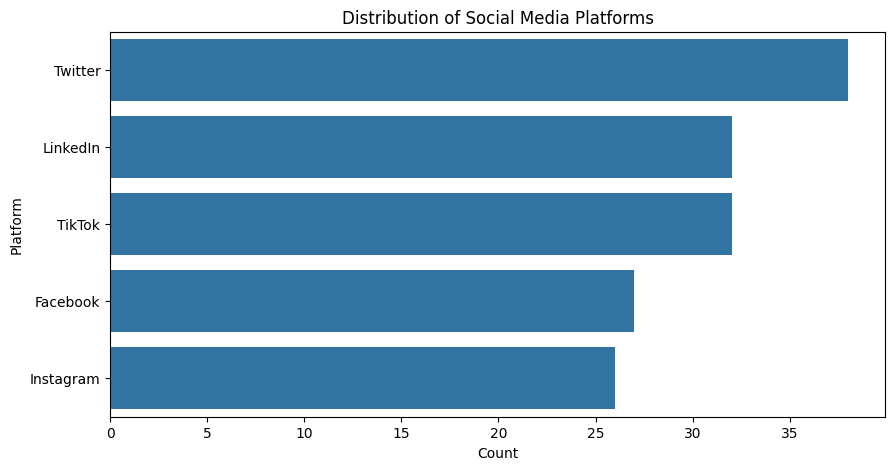

In [5]:
# Analysing which social medias are more prevalent in the data
plt.figure(figsize=(10, 5))
sns.countplot(
    y=social_df['social_media_platform'],
    order=social_df['social_media_platform'].value_counts().index,
)
plt.title('Distribution of Social Media Platforms')
plt.xlabel('Count')
plt.ylabel('Platform')
plt.show()

## Merging datasets

In [6]:
merged_df = pd.merge(social_df, trans_df, on='customer_id_new', how='inner')

# Check merge success
print("Merged shape:", merged_df.shape)
print("Sample merged data:\n", merged_df.head())

Merged shape: (219, 11)
Sample merged data:
   customer_id_new social_media_platform  engagement_score  \
0            A190               Twitter                82   
1            A190               Twitter                82   
2            A150              Facebook                96   
3            A150              Facebook                96   
4            A162               Twitter                89   

   purchase_interest_score review_sentiment  customer_id_legacy  \
0                      4.8          Neutral                 190   
1                      4.8          Neutral                 190   
2                      1.6         Positive                 150   
3                      1.6         Positive                 150   
4                      2.6         Positive                 162   

   transaction_id  purchase_amount purchase_date product_category  \
0            1031              333    2024-01-31        Groceries   
1            1140              401    2024-05-1

**We performed an inner join on the customer_id_new column, which we had previously engineered in the transactions DataFrame and which already existed in the social DataFrame. We chose an inner join to ensure that we only retained records for customers who were present in both datasets, as our analysis and model needs customers with both transactional and social data.**

## Analysing data post merge

In [7]:
# Check for missing values
print("Nulls:\n", merged_df.isnull().sum())

# Check for duplicates
print("Duplicates:", merged_df.duplicated().sum())

# Convert data types (making sure purchase_date is a date)
merged_df['purchase_date'] = pd.to_datetime(merged_df['purchase_date'])

# Drop unused legacy ID
merged_df.drop(columns=['customer_id_legacy'], inplace=True)

Nulls:
 customer_id_new             0
social_media_platform       0
engagement_score            0
purchase_interest_score     0
review_sentiment            0
customer_id_legacy          0
transaction_id              0
purchase_amount             0
purchase_date               0
product_category            0
customer_rating            19
dtype: int64
Duplicates: 6


In [8]:
# Fill missing customer_rating
merged_df['customer_rating'].fillna(merged_df['customer_rating'].median(), inplace=True)

C:\Users\mbric\AppData\Local\Temp\ipykernel_17248\2662877689.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  merged_df['customer_rating'].fillna(merged_df['customer_rating'].median(), inplace=True)


0      3.8
1      4.9
2      3.2
3      3.6
4      4.2
      ... 
214    3.2
215    3.2
216    3.0
217    4.2
218    1.4
Name: customer_rating, Length: 219, dtype: float64

In [9]:
# Check for missing values
print("Nulls:\n", merged_df.isnull().sum())

Nulls:
 customer_id_new             0
social_media_platform       0
engagement_score            0
purchase_interest_score     0
review_sentiment            0
transaction_id              0
purchase_amount             0
purchase_date               0
product_category            0
customer_rating            19
dtype: int64


**All missing values have been filled out**

In [10]:
# Summary statistics
print(merged_df.describe(include='all'))

# Variable Types
display(merged_df.dtypes)

       customer_id_new social_media_platform  engagement_score  \
count              219                   219        219.000000   
unique              61                     5               NaN   
top               A187               Twitter               NaN   
freq                15                    61               NaN   
mean               NaN                   NaN         75.283105   
min                NaN                   NaN         50.000000   
25%                NaN                   NaN         63.000000   
50%                NaN                   NaN         77.000000   
75%                NaN                   NaN         89.000000   
max                NaN                   NaN         99.000000   
std                NaN                   NaN         15.082715   

        purchase_interest_score review_sentiment  transaction_id  \
count                219.000000              219      219.000000   
unique                      NaN                3             NaN   
top

customer_id_new                       str
social_media_platform                 str
engagement_score                    int64
purchase_interest_score           float64
review_sentiment                      str
transaction_id                      int64
purchase_amount                     int64
purchase_date              datetime64[us]
product_category                      str
customer_rating                   float64
dtype: object

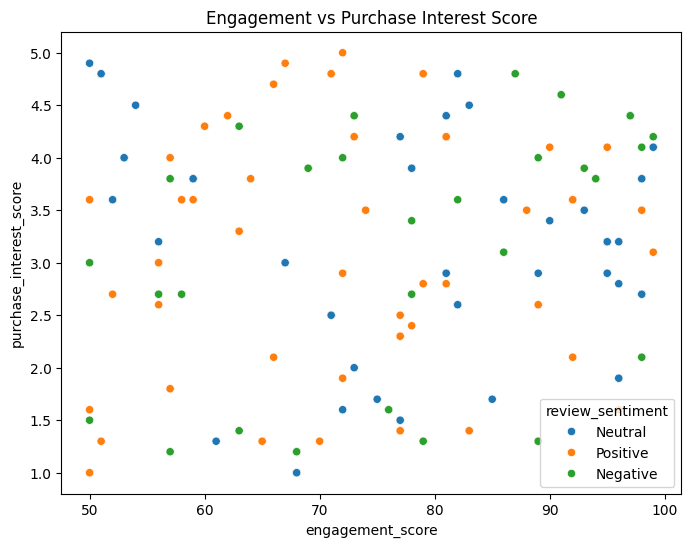

In [11]:
# Plot 1: Engagement vs Purchase Interest
plt.figure(figsize=(8, 6))
sns.scatterplot(data=merged_df, x='engagement_score', y='purchase_interest_score', hue='review_sentiment')
plt.title("Engagement vs Purchase Interest Score")
plt.show()


**The scatter plot reveals a weak positive correlation between engagement score and purchase interest, with considerable variation across all sentiment categories. Notably, customers with positive sentiment (orange) tend to cluster in the middle engagement range (60-80) but show mixed purchase interest levels. High engagement scores (80+) are present across all sentiment types, yet don't guarantee high purchase interest, suggesting that engagement alone isn't a strong predictor of buying intent.**

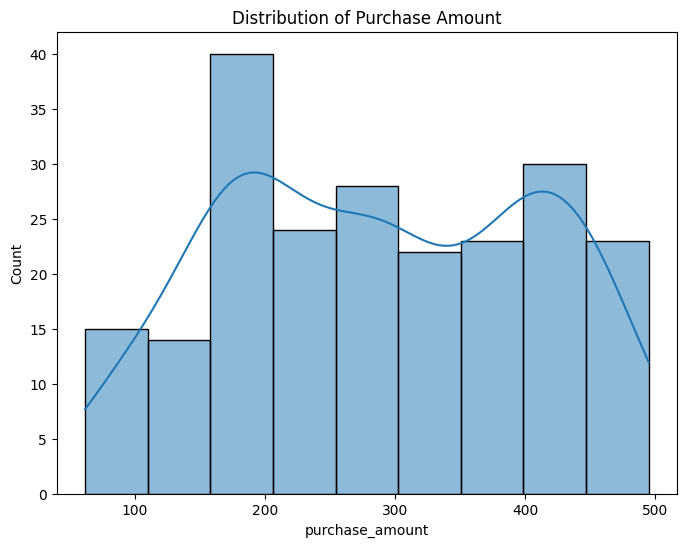

In [12]:
# Plot 2: Distribution of Purchase Amount
plt.figure(figsize=(8, 6))
sns.histplot(merged_df['purchase_amount'], kde=True)
plt.title("Distribution of Purchase Amount")
plt.show()

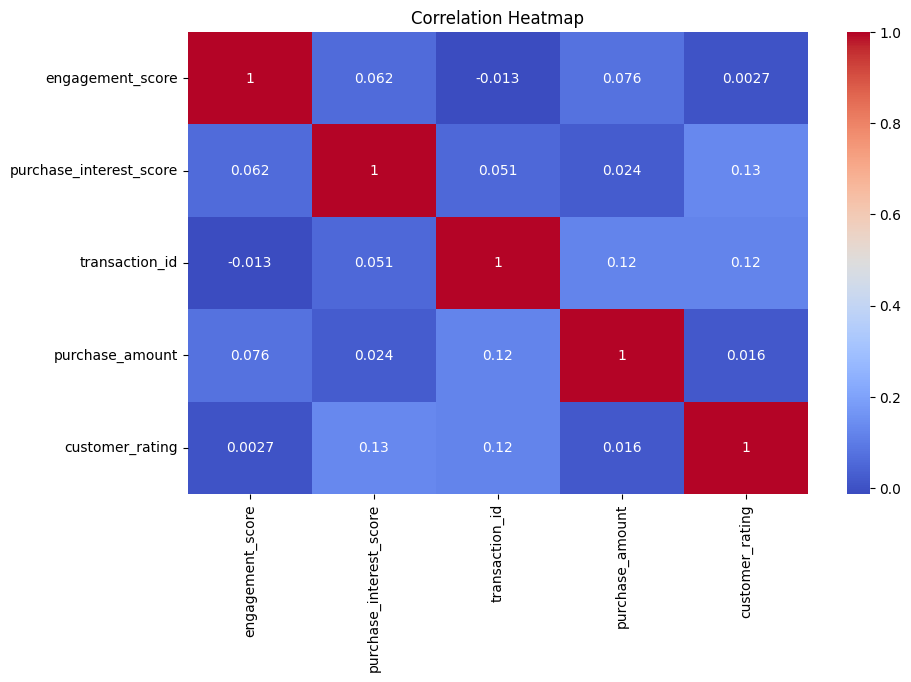

In [13]:
# Plot 3: Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(merged_df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**These low correlation values imply that none of the variables have strong linear relationships with each other.**

In [14]:
# Check unique customers
print("Unique customers in merged set:", merged_df['customer_id_new'].nunique())

# Check product categories
print("Product categories:", merged_df['product_category'].value_counts())


Unique customers in merged set: 61
Product categories: product_category
Sports         60
Electronics    46
Books          41
Groceries      39
Clothing       33
Name: count, dtype: int64


## Saving new merged and cleaned dataframe

In [15]:
# Save the final merged and cleaned dataframe
merged_df.to_csv("Data/merged_customer_data.csv", index=False)

print("Clean, merged dataset saved to 'Data/merged_customer_data.csv'.")

Clean, merged dataset saved to 'Data/merged_customer_data.csv'.
